In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv(r"C:\Users\Hello\Downloads\Retail-Business-Analytics-Portfolio\customers.csv")
products = pd.read_csv(r"C:\Users\Hello\Downloads\Retail-Business-Analytics-Portfolio\products.csv")
orders = pd.read_csv(r"C:\Users\Hello\Downloads\Retail-Business-Analytics-Portfolio\orders.csv")

In [3]:
customers.head()

products.head()

orders.head()

,order_id,order_date,customer_id,product_id,quantity,sales_amount
0,1,2025-02-23,10991,2144,3,18468
1,2,2024-05-03,10239,2024,2,1964
2,3,2025-02-25,10927,2197,3,5709
3,4,2024-08-18,10367,2169,3,19341
4,5,2025-11-20,10168,2077,3,14133


In [4]:
print(customers.shape)
print(products.shape)
print(orders.shape)

(1000, 6)
(200, 4)
(5000, 6)


In [5]:
customers.info()
products.info()
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    1000 non-null   int64
 1   customer_name  1000 non-null   str  
 2   segment        1000 non-null   str  
 3   city           1000 non-null   str  
 4   state          1000 non-null   str  
 5   region         1000 non-null   str  
dtypes: int64(1), str(5)
memory usage: 87.0 KB
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    200 non-null    int64
 1   product_name  200 non-null    str  
 2   category      200 non-null    str  
 3   unit_price    200 non-null    int64
dtypes: int64(2), str(2)
memory usage: 10.4 KB
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
-

In [6]:
customers.isnull().sum()
products.isnull().sum()
orders.isnull().sum()

order_id        0
order_date      0
customer_id     0
product_id      0
quantity        0
sales_amount    0
dtype: int64

In [7]:
customers.duplicated().sum()
products.duplicated().sum()
orders.duplicated().sum()

np.int64(0)

In [8]:
orders.describe()

,order_id,customer_id,product_id,quantity,sales_amount
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,10500.951000,2098.60380,2.993200,15810.735600
std,1443.520003,288.182361,57.50294,1.419703,11682.069293
min,1.000000,10001.000000,2001.00000,1.000000,509.000000
25%,1250.750000,10249.000000,2049.00000,2.000000,6407.000000
50%,2500.500000,10504.500000,2097.50000,3.000000,12802.000000
75%,3750.250000,10750.000000,2148.00000,4.000000,23181.000000
max,5000.000000,11000.000000,2200.00000,5.000000,49675.000000


# Merge Datasets

In [9]:
df = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

df = df.merge(
    products,
    on='product_id',
    how='left'
)

df.head()

,order_id,order_date,customer_id,product_id,quantity,sales_amount,customer_name,segment,city,state,region,product_name,category,unit_price
0,1,2025-02-23,10991,2144,3,18468,Customer_991,Corporate,Mumbai,Maharashtra,West,Product_144,Accessories,6156
1,2,2024-05-03,10239,2024,2,1964,Customer_239,Home Office,Pune,Maharashtra,West,Product_24,Furniture,982
2,3,2025-02-25,10927,2197,3,5709,Customer_927,Home Office,Mumbai,Maharashtra,West,Product_197,Furniture,1903
3,4,2024-08-18,10367,2169,3,19341,Customer_367,Corporate,Noida,Uttar Pradesh,North,Product_169,Electronics,6447
4,5,2025-11-20,10168,2077,3,14133,Customer_168,Corporate,Bhubaneswar,Odisha,East,Product_77,Electronics,4711


In [10]:
df.shape

(5000, 14)

In [11]:
df['sales_amount'].sum()

np.int64(79053678)

In [12]:
df['order_id'].nunique()

5000

In [13]:
df['customer_id'].nunique()

992

In [14]:
df['product_id'].nunique()

200

# Monthly Revenue Trend

In [15]:
df['order_date'] = pd.to_datetime(df['order_date'])

monthly_sales = df.groupby(
    df['order_date'].dt.to_period('M')
)['sales_amount'].sum()

monthly_sales

order_date
2024-01    3388766
2024-02    2506325
2024-03    3378145
2024-04    3445974
2024-05    3235498
2024-06    3453599
2024-07    3962264
2024-08    3082657
2024-09    3067238
2024-10    3302614
2024-11    2738183
2024-12    3252642
2025-01    3212760
2025-02    3347066
2025-03    3639620
2025-04    2956083
2025-05    3151430
2025-06    3252563
2025-07    3763935
2025-08    3169418
2025-09    3572113
2025-10    3577003
2025-11    3499152
2025-12    3098630
Freq: M, Name: sales_amount, dtype: int64

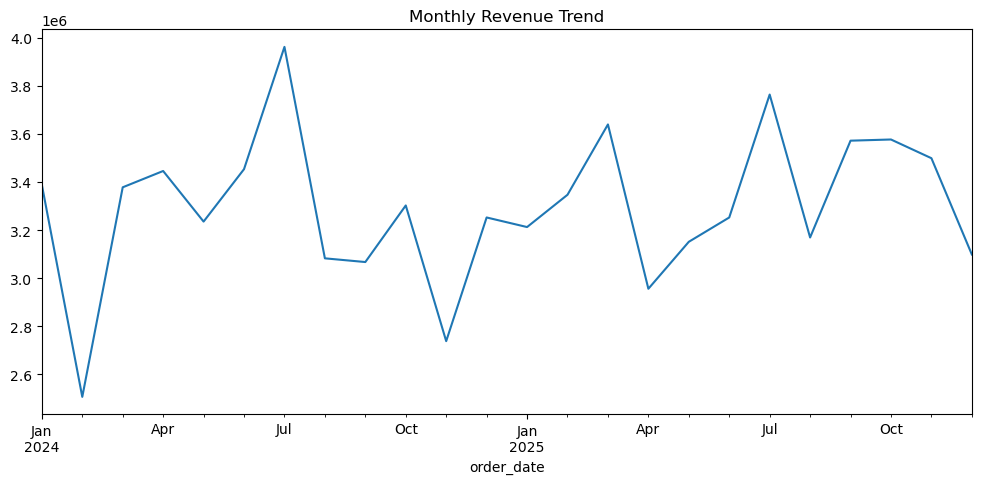

In [16]:
monthly_sales.plot(
    figsize=(12,5)
)

plt.title('Monthly Revenue Trend')
plt.show()

# Revenue by Segment

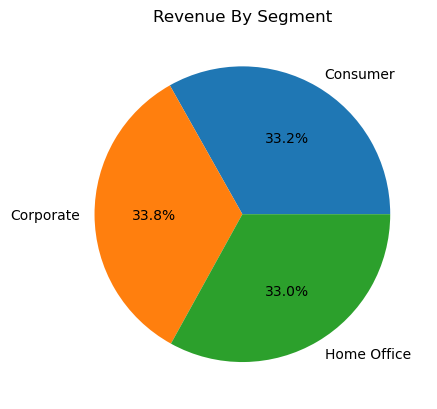

In [34]:
segment_sales = df.groupby('segment')['sales_amount'].sum()

segment_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Revenue By Segment')
plt.ylabel('')
plt.show()

# Revenue by State

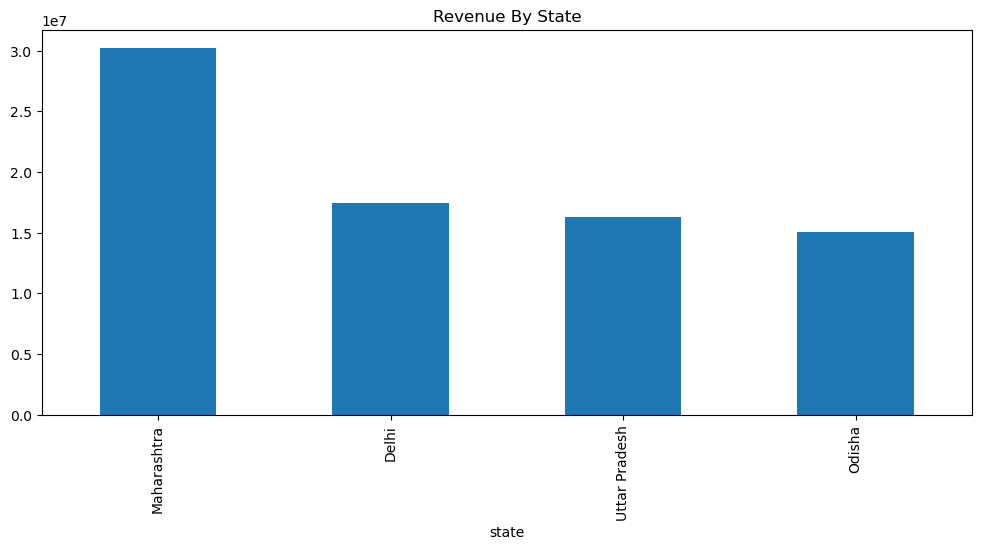

In [35]:
state_sales = df.groupby('state')['sales_amount'].sum()

state_sales.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Revenue By State')
plt.show()

# Revenue By Category

In [18]:
category_sales = df.groupby(
    'category'
)['sales_amount'].sum()

category_sales

category
Accessories    20093399
Appliances     18371472
Electronics    22243466
Furniture      18345341
Name: sales_amount, dtype: int64

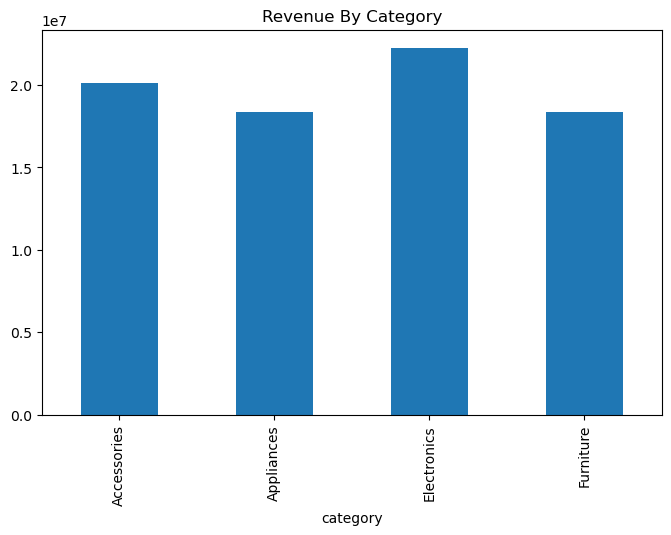

In [19]:
category_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Revenue By Category')
plt.show()

# Revenue By Region

In [20]:
region_sales = df.groupby(
    'region'
)['sales_amount'].sum()

region_sales

region
East     15071872
North    33776249
West     30205557
Name: sales_amount, dtype: int64

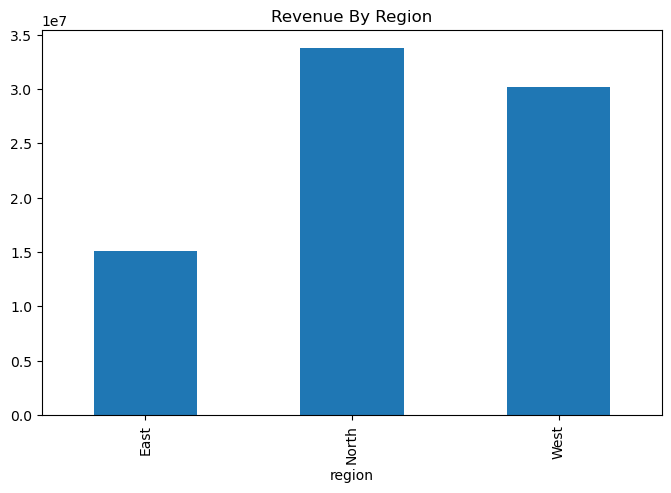

In [21]:
region_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Revenue By Region')
plt.show()

# Top 10 Customers

In [22]:
top_customers = df.groupby(
    'customer_name'
)['sales_amount'].sum().sort_values(
    ascending=False
).head(10)

top_customers

customer_name
Customer_229    271866
Customer_870    240444
Customer_754    226834
Customer_849    224664
Customer_396    223742
Customer_270    223431
Customer_668    211832
Customer_550    203660
Customer_387    194483
Customer_466    191884
Name: sales_amount, dtype: int64

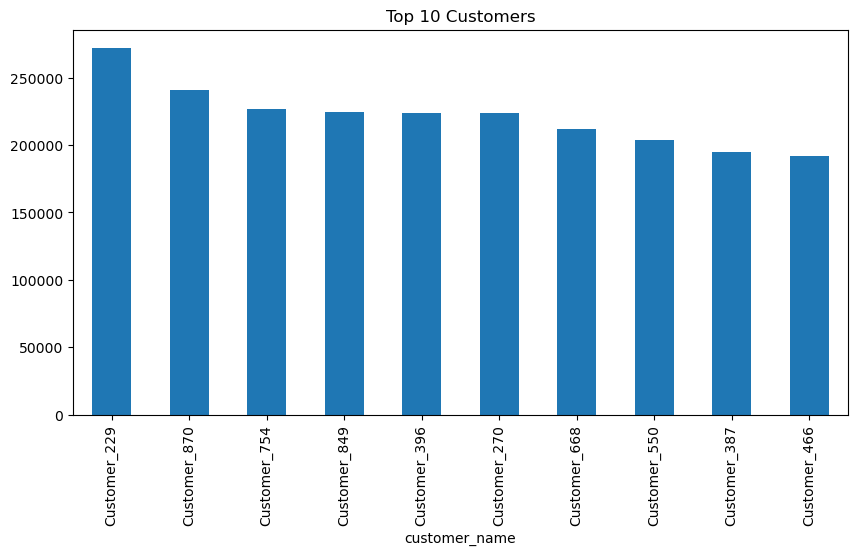

In [23]:
top_customers.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Customers')
plt.show()

# Top 10 Products

In [24]:
top_products = df.groupby(
    'product_name'
)['sales_amount'].sum().sort_values(
    ascending=False
).head(10)

top_products

product_name
Product_134    966774
Product_122    864215
Product_80     854304
Product_184    823320
Product_28     813711
Product_68     805505
Product_128    798510
Product_34     792120
Product_120    769958
Product_165    757188
Name: sales_amount, dtype: int64

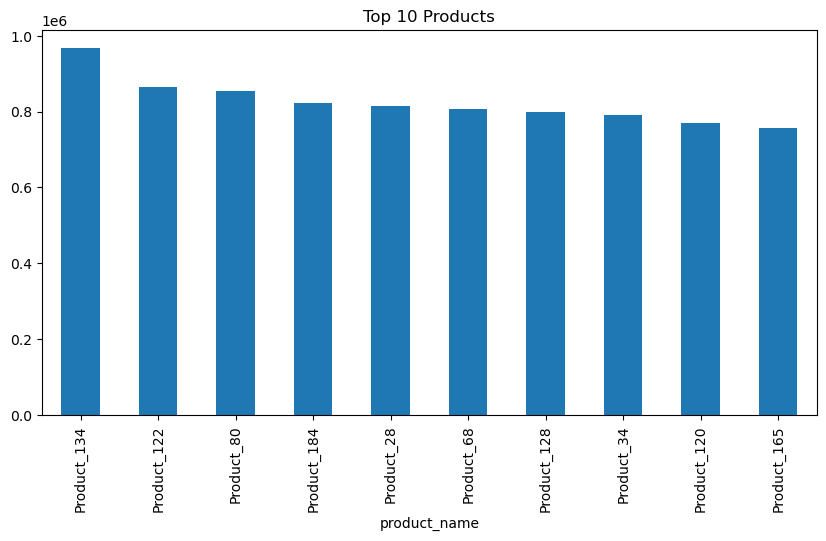

In [25]:
top_products.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Products')
plt.show()

# Customer Segment Analysis

In [26]:
segment_sales = df.groupby(
    'segment'
)['sales_amount'].sum()

segment_sales

segment
Consumer       26215858
Corporate      26731231
Home Office    26106589
Name: sales_amount, dtype: int64

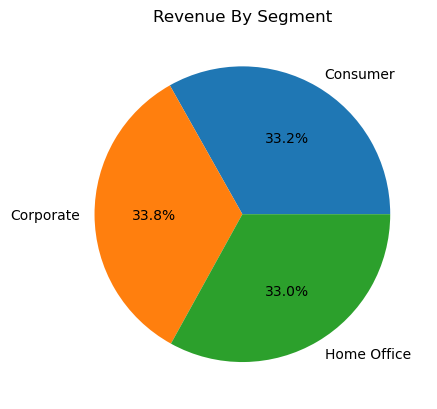

In [27]:
segment_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Revenue By Segment')
plt.ylabel('')
plt.show()

# Customer Segment Analysis

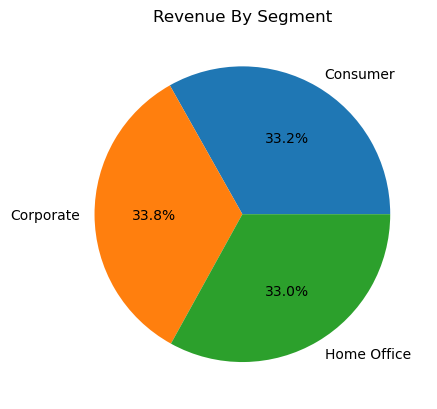

In [30]:
segment_sales = df.groupby('segment')['sales_amount'].sum()

segment_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Revenue By Segment')
plt.ylabel('')
plt.show()

# State-wise Revenue

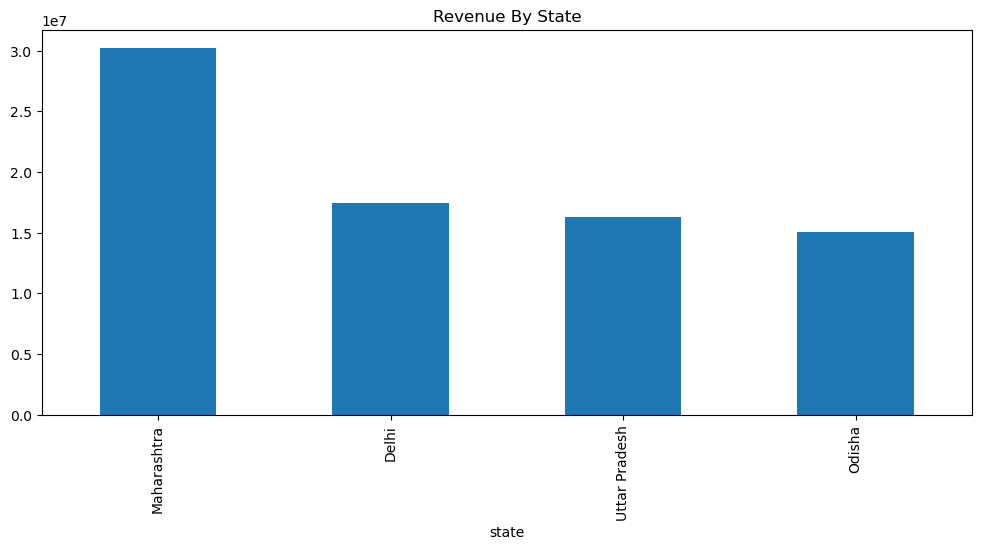

In [31]:
state_sales = df.groupby(
    'state'
)['sales_amount'].sum().sort_values(
    ascending=False
)

state_sales.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Revenue By State')
plt.show()

# Sales Distribution

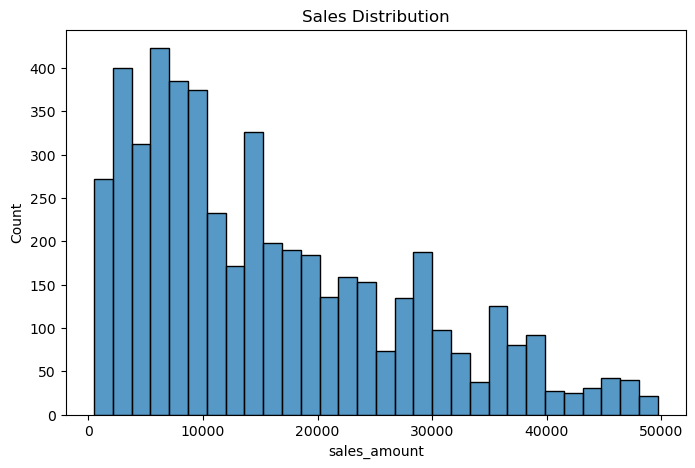

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['sales_amount'],
    bins=30
)

plt.title('Sales Distribution')
plt.show()

# Correlation Heatmap

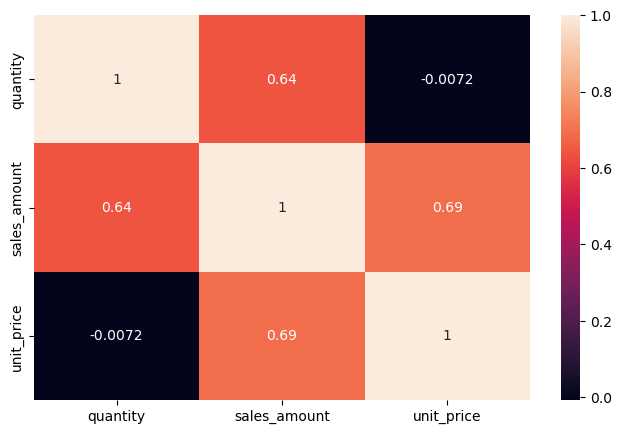

In [29]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['quantity','sales_amount','unit_price']].corr(),
    annot=True
)

plt.show()

 # Business Insights

Business Insights

1. Electronics generated the highest revenue.

2. Top 10 customers contributed significantly to sales.

3. South region generated the highest revenue.

4. Revenue showed seasonal trends across months.

5. A small group of products generated a large share of revenue.